In [2]:
import os
import datetime
import time
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter, lidar_processor
# import subroutines
# import vis_eulag

plt.style.use('latex_default.mplstyle')

"""Config"""
VERTICAL_CUTOFF = 15 # km (LAMBDA_CUT)
TEMPORAL_CUTOFF = 8*60 # min (TAU_CUT)

In [3]:
"""EULAG simulations"""
# folder = "/work/bd0620/b309199/patagonia"
folder = "/scratch/b/b309199"
# sim = "ideal_topo_L20_amp1500"
sim = "ideal_topo_L10_amp2200"
fpath = os.path.join(folder, sim)

xlid = None # CORAL
xlim_lid = [2.5, 6] #h
slices = {"x": 0, "y": 0, "z": [0,4]}

stime = time.time()
ds, dsxz, dsyz, ds_xyslices = plt_helper.preprocess_eulag_output(fpath, slices=slices, load_ds=False)
elapsed = time.time() - stime
print(f"[i]  Files loaded in {elapsed / 60:.2f}min.")

ds_slices = [dsxz, dsyz]
for ds_slc in ds_slices:
    ds_slc['tloc'] = ds_slc['th']
    ds_slc['rho_from_t'] = ds_slc['th']
    ds_slc['tloc'].values, _ = plt_helper.get_eulag_t_and_tenv(ds_slc['th'].values, ds_slc['the'].values, ds_slc['p'].values, ds_slc['ppe'].values, ds.cap, ds.pref00)
    ds_slc['rho_from_t'].values = (ds_slc['ppe'].values + ds_slc['p'].values) / (ds.rg * ds_slc['tloc'].values)
ds_slices[0]

[i]  Files loaded in 0.19min.


<xarray.Dataset> Size: 16GB
Dimensions:     (t: 1001, z: 321, x: 768, y: 768)
Coordinates:
    zcr         (t, z, x) float32 987MB 0.0 0.0 0.0 0.0 ... 128.0 128.0 128.0
    xcr         (y, x) float32 2MB -306.8 -306.0 -305.2 ... 305.2 306.0 306.8
    ycr         (y, x) float32 2MB -306.8 -306.8 -306.8 ... 306.8 306.8 306.8
    time        (t) float64 8kB 0.0 0.005 0.01 0.015 ... 4.985 4.99 4.995 5.0
Dimensions without coordinates: t, z, x, y
Data variables: (12/13)
    u           (t, z, x) float32 987MB ...
    v           (t, z, x) float32 987MB ...
    w           (t, z, x) float32 987MB ...
    th          (t, z, x) float32 987MB 0.0 0.0 0.0 ... -7.266e-12 -1.126e-12
    ue          (t, z, x) float32 987MB ...
    ve          (t, z, x) float32 987MB ...
    ...          ...
    ppe         (t, z, x) float32 987MB 9.819e+04 9.819e+04 ... 0.0007166
    p           (t, z, x) float32 987MB -8.846e-12 -8.846e-12 ... 8.236e-06
    rh0         (t, z, x) float32 987MB ...
    rho         (t, z, x) float32 987MB ...
    tloc        (t, z, x) float64 2GB 278.0 278.0 278.0 ... 499.2 499.2 499.2
    rho_from_t  (t, z, x) float64 2GB 1.231 1.231 1.231 ... 5.059e-09 5.058e-09
Attributes: (12/51)
    j:        384
    ypos:     0.0
    nt:       12000
    nx:       768
    ny:       768
    nz:       321
    ...       ...
    rg:       287.04
    u0z:      0.0
    v0z:      0.0
    pref00:   100000.0
    cp:       1004.6400000000001
    cap:      0.2857142857142857

In [4]:
def emulate_airplane_measurement(ds, speed=220, xrange=None, dim='xcr'):
    """
    Emulate an airplane flying along one slice (x-axis) with dimensions (time, z, x).
    
    Parameters:
    - ds: xarray.Dataset with dimensions (time, z, x)
    - speed: speed of the airplane in m/s
    - range: Boundaries for airplane to turn around
    
    Returns:
    - xarray.DataArray with dimensions (time, z), representing the vertical
      profile at the airplane's position at each timestep.
    """

    ## Format dataset
    # ds = ds.set_coords('time')
    if dim == 'ycr':
        ds['y'] = ds['ycr'][:,0]
        ds = ds.set_coords('y')
        ds = ds.set_index({'y':'y'})
    else:
        ds['x'] = ds['xcr'][0,:]
        ds = ds.set_coords('x')
        ds = ds.set_index({'x':'x'})
    ds = ds.reset_coords('zcr', drop=False)

    ## Get x-locations of airplane for each timestep
    if xrange is None:
        xrange  = [ds[dim].min().values, ds[dim].max().values]
    xrange = [x * 1000 for x in xrange] # meter
    
    T = (xrange[1] - xrange[0]) / speed  # time for one leg
    tau = np.mod(ds.time.values * 3600, 2 * T)
    xlocs = np.where(tau < T, # tau < T -> forward flying
                    xrange[0] + speed * tau,
                    xrange[1] - speed * (tau - T))
    
    # Extract vertical profiles for each x-location
    if dim == 'ycr':
        vertical_profiles = [
            ds.isel(t=tstep).sel(y=xloc/1000, method='nearest')
            for tstep, xloc in enumerate(xlocs)
        ]
    else:
        vertical_profiles = [
            ds.isel(t=tstep).sel(x=xloc/1000, method='nearest')
            for tstep, xloc in enumerate(xlocs)
        ]
    result = xr.concat(vertical_profiles, dim='time')
    return result, xlocs

airplane_speed = 220
vars_to_drop = ["ue", "ve", "ppe", "p", "rh0"]
dsxz = ds_slices[0].drop_vars(vars_to_drop) 
dsyz = ds_slices[1].drop_vars(vars_to_drop)
dslid_xz, alima_locs = emulate_airplane_measurement(dsxz, speed=airplane_speed, xrange=[-200,200], dim='xcr')
dslid_yz, alima_locs = emulate_airplane_measurement(dsyz, speed=airplane_speed, xrange=[-200,200], dim='ycr')
dslid_xz

<xarray.Dataset> Size: 17MB
Dimensions:     (time: 1001, z: 321, y: 768)
Coordinates:
    xcr         (time, y) float32 3MB -199.6 -199.6 -199.6 ... -159.6 -159.6
    ycr         (y) float32 3kB -306.8 -306.0 -305.2 ... 305.2 306.0 306.8
  * time        (time) float64 8kB 0.0 0.005 0.01 0.015 ... 4.985 4.99 4.995 5.0
    x           (time) float32 4kB -199.6 -196.4 -192.4 ... -152.4 -156.4 -159.6
Dimensions without coordinates: z, y
Data variables:
    u           (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... -14.23 -14.35 -14.23
    v           (time, z) float32 1MB -0.0 -0.0 -0.0 ... -0.3099 -0.2605 -0.2847
    w           (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... 0.02426 0.01213 0.0
    th          (time, z) float32 1MB 0.0 0.0 0.0 ... -0.6643 -0.7916 7.086e-05
    zcr         (time, z) float32 1MB 0.0 0.4 0.8 1.2 ... 127.2 127.6 128.0
    the         (time, z) float32 1MB 279.4 280.0 280.6 ... 1.039e+05 1.057e+05
    rho         (time, z) float32 1MB 1.234 1.189 1.145 ... 5.136e-09 4.996e-09
    tloc        (time, z) float64 3MB 278.0 274.6 271.4 ... 488.1 491.0 494.1
    rho_from_t  (time, z) float64 3MB 1.231 1.186 1.142 ... 5.143e-09 4.93e-09
Attributes: (12/51)
    j:        384
    ypos:     0.0
    nt:       12000
    nx:       768
    ny:       768
    nz:       321
    ...       ...
    rg:       287.04
    u0z:      0.0
    v0z:      0.0
    pref00:   100000.0
    cp:       1004.6400000000001
    cap:      0.2857142857142857

In [5]:
## Write vlidar to NETCDF
dslid_xz.to_netcdf(os.path.join(fpath, f"valima_x_{airplane_speed}.nc"))
dslid_yz.to_netcdf(os.path.join(fpath, f"valima_y_{airplane_speed}.nc"))

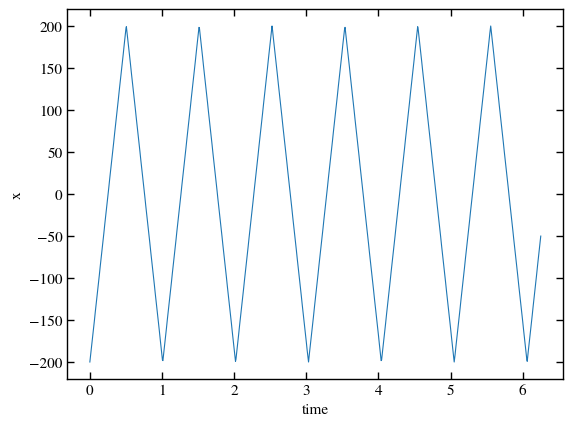

In [8]:
dslid_xz.x.plot()

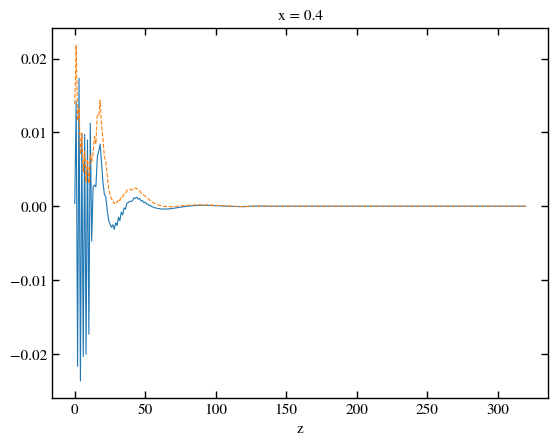

In [9]:
# dsxz['rhoprime'] = dsxz['rho'] - dsxz['rh0']
(dsxz['rho'][-1,:,384]-dsxz['rho_from_t'][0,:,384]).plot()
(dsxz['rho_from_t'][-1,:,384]-dsxz['rho_from_t'][0,:,384]).plot(ls="--")